In [1]:
import aotools
import numpy
import matplotlib.pyplot as plt
from astropy.io import fits
from PIL import Image
from tqdm import tqdm, trange, tqdm_notebook
import scipy.signal
import sys,os

In [2]:
data = fits.getdata('tabai5mm.fits')
data[:,:,0:2]=0
array_size=128
padding=2
wavelength=833e-3 #(this is the wavelength data was taken at in microns)
wavelength_m=833e-9
diameter=5e-3 #(pupil diameter in m)
psf_size=array_size*padding
j=0+1j
print(data.shape)

(50, 808, 65)


In [3]:
imfolder='eccentricities'
im1_=Image.open(os.path.join(imfolder,os.listdir(imfolder)[0]))
im1=numpy.asarray(im1_)
w,h =im1.shape
imarray=numpy.zeros((5,w,h))


#make sure you match the 
files=os.listdir(imfolder)

for n in range(5):
    filename=files[n]
    im = Image.open(os.path.join(imfolder,filename))
    image=numpy.asarray(im)
    imarray[n]=image
    

In [4]:
pixel_scale_psf= wavelength_m/(padding*diameter)
pixel_scale_psf_arcmin = (pixel_scale_psf * 180.0 * 60)/numpy.pi
print('The pixel scale of the psf in arcminutes is: %f'%(pixel_scale_psf_arcmin))

The pixel scale of the psf in arcminutes is: 0.286364


In [5]:
n_pixels_image=im1.shape[0]
fov_arcmin=60*2
pixel_scale_image_arcmin=fov_arcmin/n_pixels_image
print('The pixel scale of the image in arcminutes is: %f'%(pixel_scale_image_arcmin))


The pixel scale of the image in arcminutes is: 0.220183


In [6]:
padding_factor=pixel_scale_psf_arcmin/pixel_scale_image_arcmin
print(padding_factor)

1.3005712231123339


In [7]:
frames = data.shape[0]*5
psfs=numpy.load('psf_file.npy')

In [7]:
# check how long it takes to do this for first 100 timepoints
z=aotools.zernikeArray(66,array_size)
z=z[1:] #zernikearray creates an array with piston - our data does not have piston in it, so remove this
#reshape into a 65 x (array_size*array_size) array
zflat=numpy.reshape(z, (z.shape[0],z.shape[1]*z.shape[2]))
psf_size=int(array_size*padding*padding_factor)
padded_pupil = numpy.zeros((psf_size, psf_size), dtype=numpy.complex64)
psfs = numpy.zeros((frames, psf_size, psf_size))
wfs = numpy.zeros((frames, array_size, array_size))
o=0
for n in range(0,50):
    for m in range(0,5):
        
        #print(n,m)
        dat = data[n,m,:]
        #print(dat.shape)


        #convert to radians!
        wf = numpy.dot(dat,zflat)
        wf = numpy.reshape(wf, (z.shape[1],z.shape[2]))
        wf*=aotools.circle(array_size/2, array_size)
        wf*=(2*numpy.pi)/wavelength #convert to radians
        wfs[o]=wf
        complex_phase = numpy.exp(j*wf)
        
        padded_pupil[:array_size, :array_size] = complex_phase
        
        psf = numpy.abs(aotools.ft2(padded_pupil, delta=diameter/array_size))**2
        psfs[o] = psf

        o=o+1




#get the eye data
#calc all psfs
#potentially save array of psfs as a .npy?

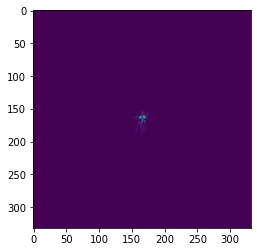

In [8]:
plt.imshow(psfs[0])

In [9]:
numpy.save('psf_file',psfs)

In [10]:
eedata=[]


for n in range(len(psfs)):
    e=aotools.encircled_energy(psfs[n], fraction=0.5, center=None, eeDiameter=True)
    eedata.append(e)

In [11]:
print(eedata)

[13.520361990950226, 13.770739064856713, 13.019607843137255, 13.26998491704374, 12.76923076923077, 23.535444947209655, 23.78582202111614, 23.78582202111614, 23.285067873303166, 22.53393665158371, 32.29864253393665, 32.29864253393665, 32.29864253393665, 30.79638009049774, 31.547511312217196, 37.80693815987934, 37.30618401206637, 37.30618401206637, 39.30920060331825, 37.55656108597285, 20.28054298642534, 20.28054298642534, 20.78129713423831, 20.530920060331823, 20.030165912518854, 19.279034690799396, 16.524886877828052, 18.277526395173453, 16.77526395173454, 18.02714932126697, 38.55806938159879, 38.808446455505276, 39.05882352941177, 38.808446455505276, 39.55957767722474, 40.81146304675716, 41.061840120663646, 41.061840120663646, 41.061840120663646, 41.31221719457014, 8.012066365007541, 8.763197586727, 8.512820512820513, 8.763197586727, 8.763197586727, 12.018099547511312, 12.268476621417797, 12.018099547511312, 12.76923076923077, 11.51734539969834, 19.279034690799396, 19.02865761689291, 

In [12]:
print(len(eedata))

250


Work out what unit this actually is - we could ask the aotools guys?

ERICA images

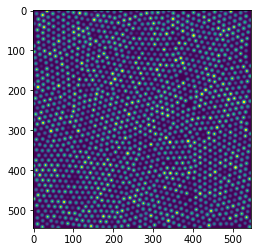

In [89]:
plt.imshow(imarray[4])

load convarray

In [90]:
test=numpy.load('eccentricity3_convolutions.npy')

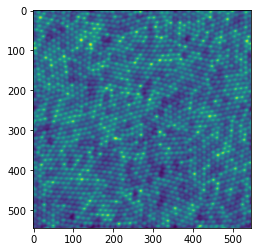

In [91]:
plt.imshow(test[0])

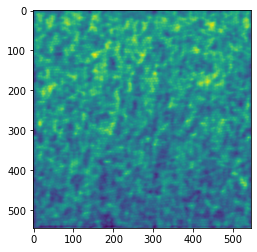

In [98]:
test2=numpy.load('eccentricity0_convolutions.npy')
plt.imshow(test2[0])

In [99]:
convarray0=numpy.load('eccentricity0_convolutions.npy')
convarray1=numpy.load('eccentricity1_convolutions.npy')
convarray2=numpy.load('eccentricity2_convolutions.npy')
convarray3=numpy.load('eccentricity3_convolutions.npy')
convarray4=numpy.load('eccentricity4_convolutions.npy')


In [50]:
print(convarray1.max())
print(convarray1.min())

7.311354279890801e-07
8.396816579829024e-08


In [100]:
convarray0=(convarray0-convarray0.min())/(convarray0.max()-convarray0.min())
convarray1=(convarray1-convarray1.min())/(convarray1.max()-convarray1.min())
convarray2=(convarray2-convarray2.min())/(convarray2.max()-convarray2.min())
convarray3=(convarray3-convarray3.min())/(convarray3.max()-convarray3.min())
convarray4=(convarray4-convarray4.min())/(convarray4.max()-convarray4.min())

In [101]:
def sqlaplace(imagedata): #this is the sharpness metric code
    
    arrl=numpy.gradient(imagedata)
    laplace = ((numpy.gradient(arrl[0])[0])+(numpy.gradient(arrl[1])[1]))**2
    S=numpy.sum(laplace)
    
    return S,laplace

def riemann(imagedata):
    arr=1+(numpy.gradient(imagedata)[0])**2+((numpy.gradient(imagedata)[1])**2-(numpy.gradient(imagedata)[0])**2)*(numpy.gradient(imagedata)[1])**2
    S=(1/(imagedata.shape[0]*imagedata.shape[1]))*numpy.nansum(abs(arr))
    return S,arr


In [102]:
print(convarray1.shape)

(250, 545, 545)


In [103]:
sd0=numpy.zeros((convarray0.shape[0]))
sql0=numpy.zeros((convarray0.shape[0]))
rie0=numpy.zeros((convarray0.shape[0]))

for c in range(convarray0.shape[0]):

    sd0[c]=numpy.std(convarray0[c])
    sql0[c]=sqlaplace(convarray0[c])[0]
    rie0[c]=riemann(convarray0[c])[0]

In [104]:
sd1=numpy.zeros((convarray1.shape[0]))
sql1=numpy.zeros((convarray1.shape[0]))
rie1=numpy.zeros((convarray1.shape[0]))

for c in range(convarray1.shape[0]):

    sd1[c]=numpy.std(convarray1[c])
    sql1[c]=sqlaplace(convarray1[c])[0]
    rie1[c]=riemann(convarray1[c])[0]

In [105]:
sd2=numpy.zeros((convarray2.shape[0]))
sql2=numpy.zeros((convarray2.shape[0]))
rie2=numpy.zeros((convarray2.shape[0]))

for c in range(convarray2.shape[0]):

    sd2[c]=numpy.std(convarray2[c])
    sql2[c]=sqlaplace(convarray2[c])[0]
    rie2[c]=riemann(convarray2[c])[0]

In [106]:
sd3=numpy.zeros((convarray3.shape[0]))
sql3=numpy.zeros((convarray3.shape[0]))
rie3=numpy.zeros((convarray3.shape[0]))

for c in range(convarray3.shape[0]):

    sd3[c]=numpy.std(convarray3[c])
    sql3[c]=sqlaplace(convarray3[c])[0]
    rie3[c]=riemann(convarray3[c])[0]

In [107]:
sd4=numpy.zeros((convarray4.shape[0]))
sql4=numpy.zeros((convarray4.shape[0]))
rie4=numpy.zeros((convarray4.shape[0]))

for c in range(convarray4.shape[0]):

    sd4[c]=numpy.std(convarray4[c])
    sql4[c]=sqlaplace(convarray4[c])[0]
    rie4[c]=riemann(convarray4[c])[0]

In [61]:
encircledenergies=numpy.asarray(eedata)
print(encircledenergies.shape)
print(sd1.shape)
print(sql1.shape)
print(rie1.shape)

(250,)
(250,)
(250,)
(250,)


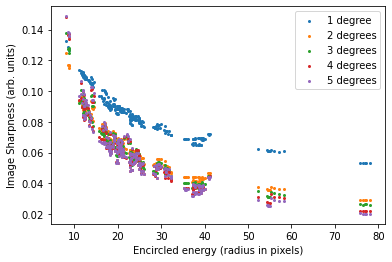

In [122]:
plt.scatter(eedata,sd0,s=4,label='1 degree')
plt.scatter(eedata,sd1,s=4,label='2 degrees')
plt.scatter(eedata,sd2,s=4,label='3 degrees')
plt.scatter(eedata,sd3,s=4,label='4 degrees')
plt.scatter(eedata,sd4,s=4,label='5 degrees')

plt.xlabel('Encircled energy (radius in pixels)')
plt.ylabel('Image Sharpness (arb. units)')

plt.legend()

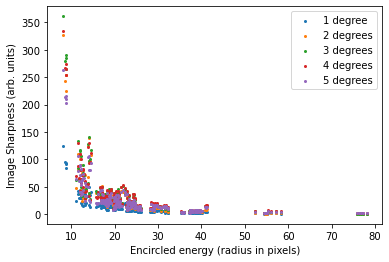

In [123]:
plt.scatter(eedata,sql0,s=4,label='1 degree')
plt.scatter(eedata,sql1,s=4,label='2 degrees')
plt.scatter(eedata,sql2,s=4,label='3 degrees')
plt.scatter(eedata,sql3,s=4,label='4 degrees')
plt.scatter(eedata,sql4,s=4,label='5 degrees')

plt.xlabel('Encircled energy (radius in pixels)')
plt.ylabel('Image Sharpness (arb. units)')

plt.legend()

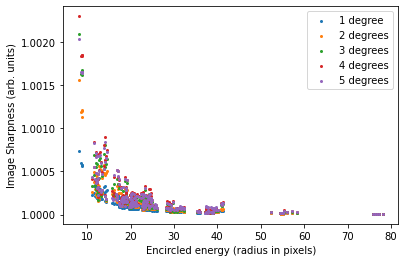

In [124]:
plt.scatter(eedata,rie0,s=4,label='1 degree')
plt.scatter(eedata,rie1,s=4,label='2 degrees')
plt.scatter(eedata,rie2,s=4,label='3 degrees')
plt.scatter(eedata,rie3,s=4,label='4 degrees')
plt.scatter(eedata,rie4,s=4,label='5 degrees')

plt.xlabel('Encircled energy (radius in pixels)')
plt.ylabel('Image Sharpness (arb. units)')

plt.legend()

now the other plots

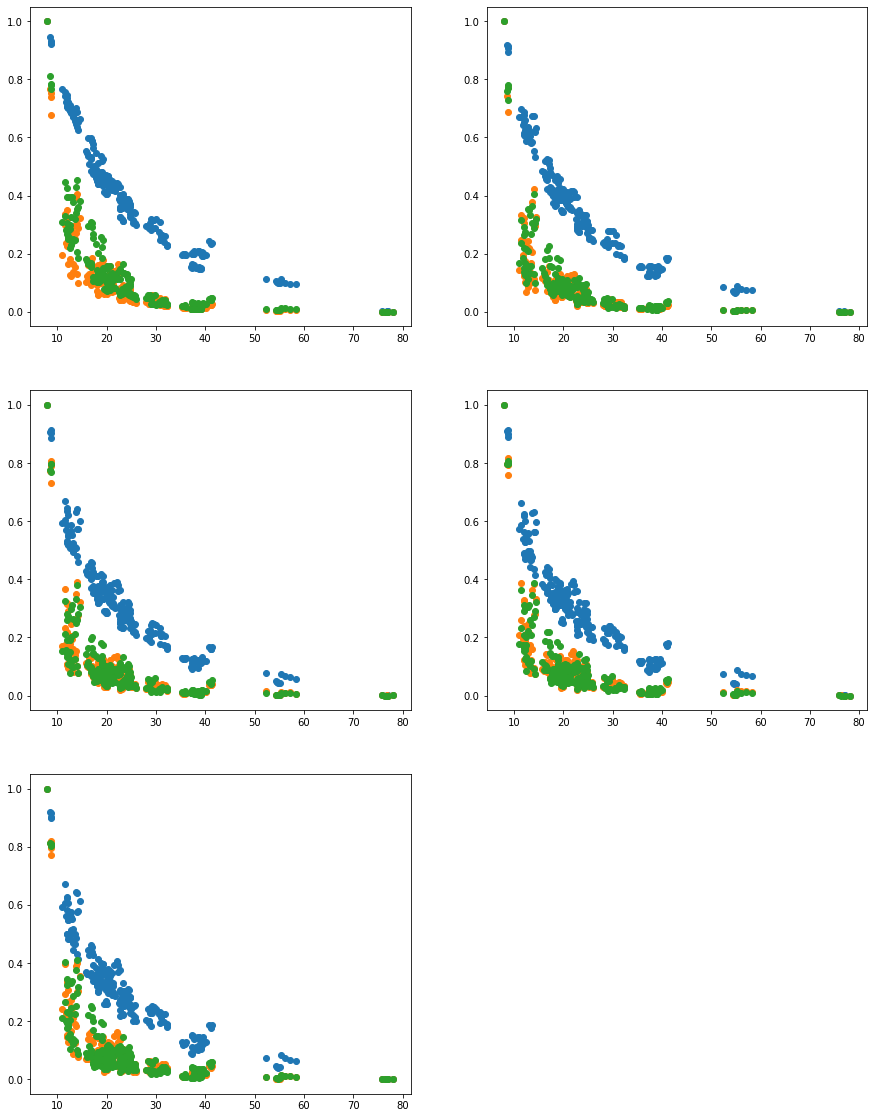

In [121]:
fig2 = plt.figure(2,figsize=(15,20))

ax1=fig2.add_subplot(3,2,1)
ax2=fig2.add_subplot(3,2,2)
ax3=fig2.add_subplot(3,2,3)
ax4=fig2.add_subplot(3,2,4)
ax5=fig2.add_subplot(3,2,5)

sd1norm=(sd1-sd1.min())/(sd1.max()-sd1.min())
sql1norm=(sql1-sql1.min())/(sql1.max()-sql1.min())
rie1norm=(rie1-rie1.min())/(rie1.max()-rie1.min())

sd2norm=(sd2-sd2.min())/(sd2.max()-sd2.min())
sql2norm=(sql2-sql2.min())/(sql2.max()-sql2.min())
rie2norm=(rie2-rie2.min())/(rie2.max()-rie2.min())

sd3norm=(sd3-sd3.min())/(sd3.max()-sd3.min())
sql3norm=(sql3-sql3.min())/(sql3.max()-sql3.min())
rie3norm=(rie3-rie3.min())/(rie3.max()-rie3.min())

sd4norm=(sd4-sd4.min())/(sd4.max()-sd4.min())
sql4norm=(sql4-sql4.min())/(sql4.max()-sql4.min())
rie4norm=(rie4-rie4.min())/(rie4.max()-rie4.min())

sd0norm=(sd0-sd0.min())/(sd0.max()-sd0.min())
sql0norm=(sql0-sql0.min())/(sql0.max()-sql0.min())
rie0norm=(rie0-rie0.min())/(rie0.max()-rie0.min())


ax1.scatter(eedata,sd0norm)
ax1.scatter(eedata,sql0norm)
ax1.scatter(eedata,rie0norm) 
    
ax2.scatter(eedata,sd1norm)
ax2.scatter(eedata,sql1norm)
ax2.scatter(eedata,rie1norm)  

ax3.scatter(eedata,sd2norm)
ax3.scatter(eedata,sql2norm)
ax3.scatter(eedata,rie2norm) 

ax4.scatter(eedata,sd3norm)
ax4.scatter(eedata,sql3norm)
ax4.scatter(eedata,rie3norm) 

ax5.scatter(eedata,sd4norm)
ax5.scatter(eedata,sql4norm)
ax5.scatter(eedata,rie4norm)  

plt.savefig('Figure2.png')

In [24]:
#import ERICA images for 5 eccentricities
#apply all aberrations to all images
#calculate 3x sharpness metrics for all images with all eccentricities

In [25]:
#plot 5x graphs, on each graph 3 sharpness metrics vs encircled energy, colour by sharpness metric.  Compare.

In [67]:
npyfiles=os.listdir('npyfiles')
print(npyfiles)

['eccentricity1_convolutions.npy', 'eccentricity2_convolutions.npy', 'eccentricity3_convolutions.npy', 'eccentricity4_convolutions.npy', 'eccentricity5_convolutions.npy']


In [75]:
sd=numpy.zeros((5,250))
sql=numpy.zeros((5,250))
rie=numpy.zeros((5,250))

0
1
2
3
4


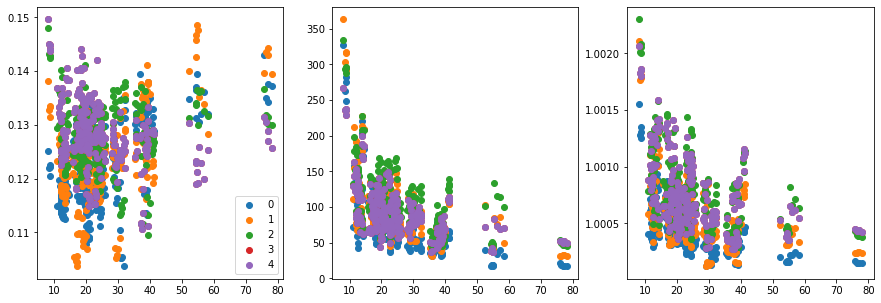

In [81]:
fig1 = plt.figure(1,figsize=(15,5))

ax1=fig1.add_subplot(1,3,1)
ax2=fig1.add_subplot(1,3,2)
ax3=fig1.add_subplot(1,3,3)




for n in range(0,len(npyfiles)):
    print (n)
    images=numpy.load(os.path.join('npyfiles',npyfiles[n]))
    for i in range(0,images.shape[0]):
        im=images[i]
        im_=(im-im.min())/(im.max()-im.min())
        sd[n,i]=numpy.std(im_)
        sql[n,i]=sqlaplace(im_)[0]
        rie[n,i]=riemann(im_)[0]
        
    ax1.scatter(eedata,sd[n],label='%i'%n)

    ax2.scatter(eedata,sql[n],label='%i'%n)

    ax3.scatter(eedata,rie[n],label='%i'%n)    
ax1.legend()        

4.5343377386755775e-07 4.178094496091018e-08
[0.12442849 0.12460527 0.12635587 0.12547048 0.12846139 0.1420075
 0.13195414 0.13427831 0.12849759 0.13590407 0.12204852 0.12511915
 0.12672975 0.13242401 0.12750785 0.11356659 0.11158639 0.11164748
 0.11112159 0.11071169 0.11947913 0.1206541  0.12479777 0.12209539
 0.12125108 0.1284524  0.13314102 0.13505904 0.12547668 0.13151108
 0.12543883 0.12464845 0.12738331 0.12603763 0.12651147 0.12856
 0.12881635 0.12897189 0.12863414 0.12823088 0.1496398  0.14415329
 0.14501034 0.14370173 0.14486582 0.13191485 0.13068928 0.13078659
 0.12895448 0.13216878 0.1309151  0.13108938 0.13249665 0.13552987
 0.13590405 0.12007932 0.1231968  0.12749174 0.12447744 0.1279994
 0.12093619 0.12754125 0.12818778 0.11815175 0.12967116 0.12689826
 0.12569022 0.12796163 0.12742006 0.1307047  0.13232307 0.13549792
 0.12987287 0.13548982 0.13049744 0.1388021  0.13835312 0.13828777
 0.13585372 0.14056001 0.12961377 0.12730834 0.13228445 0.12953976
 0.12784182 0.12824696

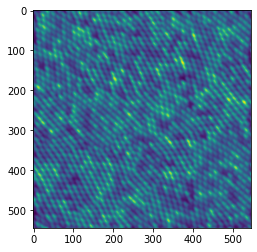

In [83]:
plt.imshow(im)
print(images[0].max(),images[0].min())
print(sd[4,:])

First set of plots - 3 plots.  one for each sharpness metric, 5 eccentricities on each one

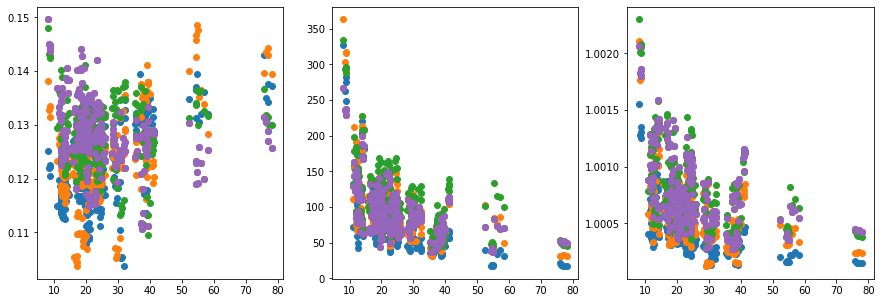

In [71]:
fig1 = plt.figure(1,figsize=(15,5))

ax1=fig1.add_subplot(1,3,1)
ax2=fig1.add_subplot(1,3,2)
ax3=fig1.add_subplot(1,3,3)

for n in range(0,5):
    ax1.scatter(eedata,sd[n,:])

    ax2.scatter(eedata,sql[n,:])

    ax3.scatter(eedata,rie[n,:])

plt.savefig('Figure1.png')

Second plots - 5 plots, one for each eccentricity, 3 metric on each one.  You must normalise each one for this.  

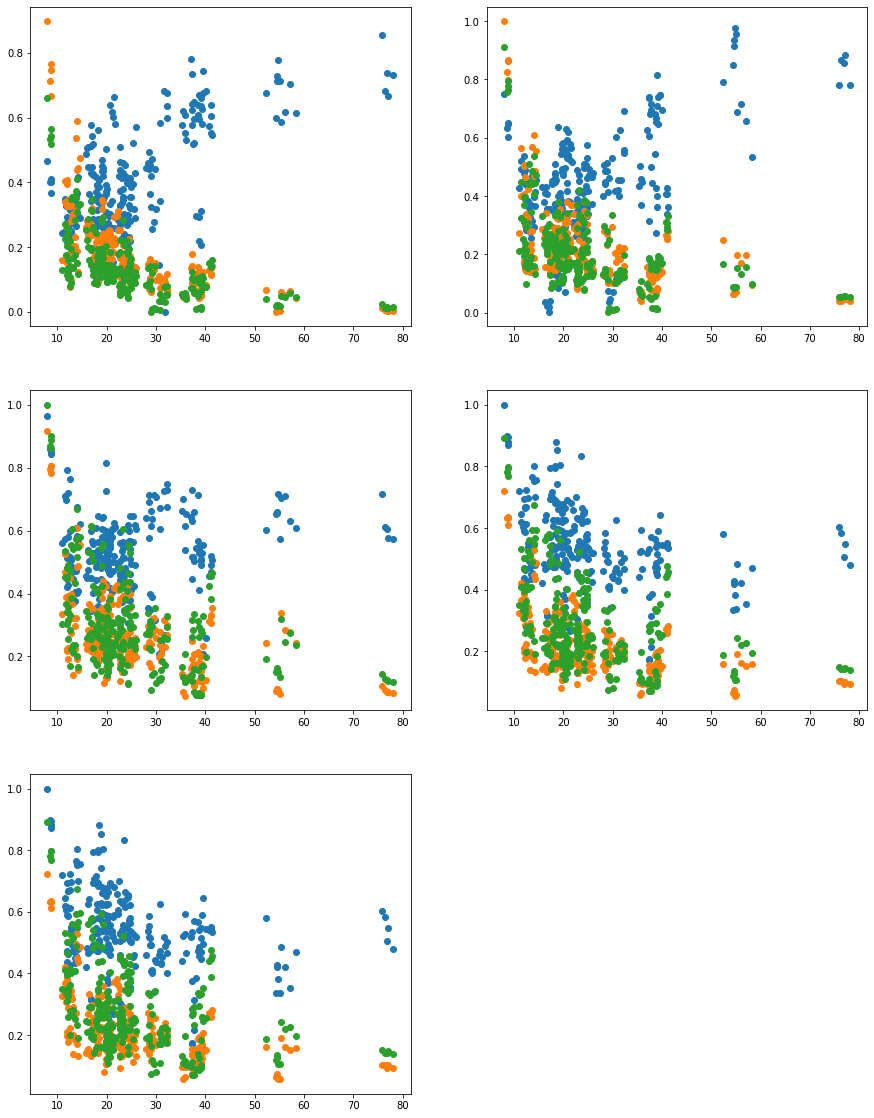

In [70]:
fig2 = plt.figure(2,figsize=(15,20))

ax1=fig2.add_subplot(3,2,1)
ax2=fig2.add_subplot(3,2,2)
ax3=fig2.add_subplot(3,2,3)
ax4=fig2.add_subplot(3,2,4)
ax5=fig2.add_subplot(3,2,5)

sd_=(sd-sd.min())/(sd.max()-sd.min())
sql_=(sql-sql.min())/(sql.max()-sql.min())
rie_=(rie-rie.min())/(rie.max()-rie.min())


ax1.scatter(eedata,sd_[0])
ax1.scatter(eedata,sql_[0])
ax1.scatter(eedata,rie_[0]) 
    
ax2.scatter(eedata,sd_[1])
ax2.scatter(eedata,sql_[1])
ax2.scatter(eedata,rie_[1]) 

ax3.scatter(eedata,sd_[2])
ax3.scatter(eedata,sql_[2])
ax3.scatter(eedata,rie_[2])

ax4.scatter(eedata,sd_[3])
ax4.scatter(eedata,sql_[3])
ax4.scatter(eedata,rie_[3])

ax5.scatter(eedata,sd_[4])
ax5.scatter(eedata,sql_[4])
ax5.scatter(eedata,rie_[4]) 

plt.savefig('Figure2.png')

the data is very messy.  Perhaps we can try averaging?

should we see what the images look like maybe?  are edge artefacts fucking shit up?  Potentially if we crop our image post-convolution that might help?

check the eedata as something odd is happening and there's a lot of grouping.  Try averaging the aberration instead of taking em all?  Could have something to do with aliasing?

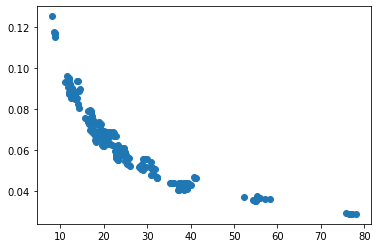

In [64]:
plt.scatter(eedata,sd)

In [65]:
OTHER STUFF TO DO

SyntaxError: invalid syntax (<ipython-input-65-2620de1d3721>, line 1)

In [ ]:
make a new notebook

In [ ]:
Put images from the registration software in it

In [ ]:
Try and make it make sense!

In [ ]:
Relate values from this to values from that